# 05 — Supervised Learning

This notebook trains three model families (Linear Regression, Random Forest, XGBoost) 
to predict next-season injury report count from player stats and history.

**Inputs:** `train.csv` (1,620 rows) and `test.csv` (412 rows) from NB04  
**Target:** `target_next_season` (injury report count for the following season)  
**Evaluation:** 5-fold CV on training set, final evaluation on held-out test set

In [7]:
import pandas as pd
import numpy as np

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor

from sklearn.model_selection import cross_val_score, GridSearchCV
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.dummy import DummyRegressor

import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# === Configuration ===
PROCESSED_DIR = '../data/processed'
TARGET = 'target_next_season'
RANDOM_STATE = 42

Let's load our traning/test split data, we should have 1,620 train / 412 test, 15 features each. 

In [8]:
# Load train and test sets from NB04
train_df = pd.read_csv(f'{PROCESSED_DIR}/train.csv')
test_df = pd.read_csv(f'{PROCESSED_DIR}/test.csv')

# Separate features and target
X_train = train_df.drop(columns=[TARGET])
y_train = train_df[TARGET]
X_test = test_df.drop(columns=[TARGET])
y_test = test_df[TARGET]

print(f"Train: {X_train.shape[0]:,} rows, {X_train.shape[1]} features")
print(f"Test:  {X_test.shape[0]:,} rows, {X_test.shape[1]} features")
print(f"\nFeatures: {X_train.columns.tolist()}")
print(f"\nTarget distribution (train): mean={y_train.mean():.2f}, median={y_train.median():.1f}, max={y_train.max()}")

assert X_train.shape == (1620, 15), f"Expected (1620, 15), got {X_train.shape}"
assert X_test.shape == (412, 15), f"Expected (412, 15), got {X_test.shape}"

Train: 1,620 rows, 15 features
Test:  412 rows, 15 features

Features: ['min', 'gp', 'dist_miles', 'usg_pct', 'ts_pct', 'age', 'player_height_inches', 'player_weight', 'injured_last_season', 'injury_report_count_last_season', 'b2b_games', 'age_x_minutes', 'weight_x_minutes', 'b2b_x_minutes', 'age_x_weight']

Target distribution (train): mean=1.41, median=1.0, max=11


## 5.3 Baseline Model

Before training any real models, we need a "do nothing" benchmark to compare against.

The baseline simply predicts the training set's mean injury count for every player. 
If our models can't beat this, they haven't learned anything useful from the features.

We track three metrics:
- **MAE** (Mean Absolute Error): average prediction error in injury report counts
- **RMSE** (Root Mean Squared Error): penalizes large misses more heavily
- **R²**: proportion of variance explained (baseline should be ~0.0 by definition)

In [9]:
# Baseline: always predict the training set mean
baseline = DummyRegressor(strategy='mean')
baseline.fit(X_train, y_train)

y_pred_base = baseline.predict(X_test)

print(f"Baseline (predict mean = {y_train.mean():.3f})")
print(f"  MAE:  {mean_absolute_error(y_test, y_pred_base):.3f}")
print(f"  RMSE: {np.sqrt(mean_squared_error(y_test, y_pred_base)):.3f}")
print(f"  R²:   {r2_score(y_test, y_pred_base):.3f}")

Baseline (predict mean = 1.413)
  MAE:  1.048
  RMSE: 1.250
  R²:   -0.032


## 5.4 Linear Regression

Linear Regression provides an interpretable benchmark for evaluating whether the selected features contain useful approximately linear predictive signal. We evaluate it with five-fold cross-validation on the training set and then score it on the held-out temporal test set.


In [10]:
# Linear Regression with 5-fold CV
lr = LinearRegression()

# Cross-validation on training set (negative MAE — sklearn convention)
lr_cv_scores = cross_val_score(lr, X_train, y_train, cv=5, scoring='neg_mean_absolute_error')
lr_cv_mae = -lr_cv_scores

print("Linear Regression — 5-Fold CV (train):")
print(f"  MAE per fold: {lr_cv_mae.round(3)}")
print(f"  MAE mean ± std: {lr_cv_mae.mean():.3f} ± {lr_cv_mae.std():.3f}")

# Fit on full training set, evaluate on test
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)

print(f"\nTest set results:")
print(f"  MAE:  {mean_absolute_error(y_test, y_pred_lr):.3f}")
print(f"  RMSE: {np.sqrt(mean_squared_error(y_test, y_pred_lr)):.3f}")
print(f"  R²:   {r2_score(y_test, y_pred_lr):.3f}")

Linear Regression — 5-Fold CV (train):
  MAE per fold: [1.176 1.344 1.163 1.08  1.024]
  MAE mean ± std: 1.158 ± 0.109

Test set results:
  MAE:  0.928
  RMSE: 1.172
  R²:   0.093


### Linear Regression vs. Baseline

| Metric | Baseline | Linear Regression | Improvement |
|---|---:|---:|---:|
| MAE | 1.048 | **0.928** | ↓ 11.5% |
| RMSE | 1.250 | **1.172** | ↓ 6.2% |
| R² | -0.032 | **0.093** | ↑ 0.125 |

Linear Regression provides a modest improvement over the mean-prediction baseline. The held-out R² of 0.093 indicates that most variation in next-season injury-report counts remains unexplained by the available features.


## 5.5 Random Forest

Tree-based ensemble that can capture non-linear relationships and feature interactions 
automatically. We start with a default model, then tune hyperparameters.

In [11]:
# Random Forest — default first, then tune
rf_default = RandomForestRegressor(n_estimators=100, random_state=RANDOM_STATE)

rf_cv_scores = cross_val_score(rf_default, X_train, y_train, cv=5, scoring='neg_mean_absolute_error')
rf_cv_mae = -rf_cv_scores

print("Random Forest (default) — 5-Fold CV (train):")
print(f"  MAE per fold: {rf_cv_mae.round(3)}")
print(f"  MAE mean ± std: {rf_cv_mae.mean():.3f} ± {rf_cv_mae.std():.3f}")

# Test set
rf_default.fit(X_train, y_train)
y_pred_rf = rf_default.predict(X_test)

print(f"\nTest set results:")
print(f"  MAE:  {mean_absolute_error(y_test, y_pred_rf):.3f}")
print(f"  RMSE: {np.sqrt(mean_squared_error(y_test, y_pred_rf)):.3f}")
print(f"  R²:   {r2_score(y_test, y_pred_rf):.3f}")

Random Forest (default) — 5-Fold CV (train):
  MAE per fold: [1.258 1.367 1.164 1.082 1.091]
  MAE mean ± std: 1.193 ± 0.108

Test set results:
  MAE:  1.006
  RMSE: 1.248
  R²:   -0.028


The default Random Forest has a higher held-out MAE than Linear Regression (1.006 vs. 0.928). We next tune the tree-based model using cross-validation to evaluate whether stronger regularization improves generalization.


### Random Forest — Hyperparameter Tuning

Default RF overfits, deep trees memorize noise in the training data instead of learning 
generalizable patterns. We use GridSearchCV to find a better balance by controlling tree 
depth, minimum samples per leaf, and number of trees.

36 parameter combinations × 5 folds

In [12]:
# Grid search over key hyperparameters
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 5, 10, None],
    'min_samples_leaf': [5, 10, 20],
}

rf_grid = GridSearchCV(
    RandomForestRegressor(random_state=RANDOM_STATE),
    param_grid,
    cv=5,
    scoring='neg_mean_absolute_error',
    n_jobs=-1
)
rf_grid.fit(X_train, y_train)

print(f"Best params: {rf_grid.best_params_}")
print(f"Best CV MAE: {-rf_grid.best_score_:.3f}")

# Test set with best model
y_pred_rf_tuned = rf_grid.best_estimator_.predict(X_test)

print(f"\nTuned RF — Test set results:")
print(f"  MAE:  {mean_absolute_error(y_test, y_pred_rf_tuned):.3f}")
print(f"  RMSE: {np.sqrt(mean_squared_error(y_test, y_pred_rf_tuned)):.3f}")
print(f"  R²:   {r2_score(y_test, y_pred_rf_tuned):.3f}")

Best params: {'max_depth': 5, 'min_samples_leaf': 10, 'n_estimators': 200}
Best CV MAE: 1.142

Tuned RF — Test set results:
  MAE:  0.964
  RMSE: 1.211
  R²:   0.033


Hyperparameter tuning improves Random Forest held-out MAE from 1.006 to 0.964, but it remains higher than Linear Regression's 0.928.


## 5.6 XGBoost

Gradient boosting builds trees sequentially: each tree corrects the previous one's errors. 
XGBoost adds regularization to prevent overfitting, which may help given our noisy target.

In [13]:
# XGBoost — default first
xgb_default = XGBRegressor(n_estimators=100, random_state=RANDOM_STATE, verbosity=0)

xgb_cv_scores = cross_val_score(xgb_default, X_train, y_train, cv=5, scoring='neg_mean_absolute_error')
xgb_cv_mae = -xgb_cv_scores

print("XGBoost (default) — 5-Fold CV (train):")
print(f"  MAE per fold: {xgb_cv_mae.round(3)}")
print(f"  MAE mean ± std: {xgb_cv_mae.mean():.3f} ± {xgb_cv_mae.std():.3f}")

# Test set
xgb_default.fit(X_train, y_train)
y_pred_xgb = xgb_default.predict(X_test)

print(f"\nTest set results:")
print(f"  MAE:  {mean_absolute_error(y_test, y_pred_xgb):.3f}")
print(f"  RMSE: {np.sqrt(mean_squared_error(y_test, y_pred_xgb)):.3f}")
print(f"  R²:   {r2_score(y_test, y_pred_xgb):.3f}")

XGBoost (default) — 5-Fold CV (train):
  MAE per fold: [1.309 1.499 1.236 1.16  1.154]
  MAE mean ± std: 1.271 ± 0.127

Test set results:
  MAE:  1.068
  RMSE: 1.374
  R²:   -0.246


Default XGBoost overfits significantly. We add regularization (learning rate, max depth, 
subsample) to slow down learning and prevent memorizing noise.

In [14]:
# Regularizations

param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [2, 3, 5],
    'learning_rate': [0.01, 0.05, 0.1],
    'subsample': [0.7, 0.8, 1.0],
}

xgb_grid = GridSearchCV(
    XGBRegressor(random_state=RANDOM_STATE, verbosity=0),
    param_grid,
    cv=5,
    scoring='neg_mean_absolute_error',
    n_jobs=-1
)
xgb_grid.fit(X_train, y_train)

print(f"Best params: {xgb_grid.best_params_}")
print(f"Best CV MAE: {-xgb_grid.best_score_:.3f}")

# Test set with best model
y_pred_xgb_tuned = xgb_grid.best_estimator_.predict(X_test)

print(f"\nTuned XGBoost — Test set results:")
print(f"  MAE:  {mean_absolute_error(y_test, y_pred_xgb_tuned):.3f}")
print(f"  RMSE: {np.sqrt(mean_squared_error(y_test, y_pred_xgb_tuned)):.3f}")
print(f"  R²:   {r2_score(y_test, y_pred_xgb_tuned):.3f}")

Best params: {'learning_rate': 0.05, 'max_depth': 2, 'n_estimators': 200, 'subsample': 0.8}
Best CV MAE: 1.130

Tuned XGBoost — Test set results:
  MAE:  0.941
  RMSE: 1.189
  R²:   0.067


Hyperparameter tuning improves XGBoost held-out MAE from 1.068 to 0.941. This is better than the mean-prediction baseline and Random Forest, but **Linear Regression remains the lowest-MAE model on the held-out test set at 0.928**.


## 5.7 Overall Results Comparison

The table below compares all models on the held-out temporal test set (2017-18 features → 2018-19 injury-report outcomes). Model conclusions are based on these held-out results rather than model complexity.


In [15]:
results = pd.DataFrame({
    'Model': ['Baseline (Mean)', 'Linear Regression', 'Random Forest (tuned)', 'XGBoost (tuned)'],
    'CV MAE (mean ± std)': [
        'N/A',
        f"{lr_cv_mae.mean():.3f} ± {lr_cv_mae.std():.3f}",
        f"{-rf_grid.best_score_:.3f} ± {rf_grid.cv_results_['std_test_score'][rf_grid.best_index_]:.3f}",
        f"{-xgb_grid.best_score_:.3f} ± {xgb_grid.cv_results_['std_test_score'][xgb_grid.best_index_]:.3f}",
    ],
    'Test MAE': [
        mean_absolute_error(y_test, y_pred_base),
        mean_absolute_error(y_test, y_pred_lr),
        mean_absolute_error(y_test, y_pred_rf_tuned),
        mean_absolute_error(y_test, y_pred_xgb_tuned),
    ],
    'Test RMSE': [
        np.sqrt(mean_squared_error(y_test, y_pred_base)),
        np.sqrt(mean_squared_error(y_test, y_pred_lr)),
        np.sqrt(mean_squared_error(y_test, y_pred_rf_tuned)),
        np.sqrt(mean_squared_error(y_test, y_pred_xgb_tuned)),
    ],
    'Test R²': [
        r2_score(y_test, y_pred_base),
        r2_score(y_test, y_pred_lr),
        r2_score(y_test, y_pred_rf_tuned),
        r2_score(y_test, y_pred_xgb_tuned),
    ]
})

results['Test MAE'] = results['Test MAE'].round(3)
results['Test RMSE'] = results['Test RMSE'].round(3)
results['Test R²'] = results['Test R²'].round(3)

print(results.to_string(index=False))

                Model CV MAE (mean ± std)  Test MAE  Test RMSE  Test R²
      Baseline (Mean)                 N/A     1.048      1.250   -0.032
    Linear Regression       1.158 ± 0.109     0.928      1.172    0.093
Random Forest (tuned)       1.142 ± 0.109     0.964      1.211    0.033
      XGBoost (tuned)       1.130 ± 0.113     0.941      1.189    0.067


## 5.8 Feature Importance (XGBoost)

Which features contribute most to predictions? We use XGBoost's built-in feature 
importance (based on how often and how much each feature improves splits).

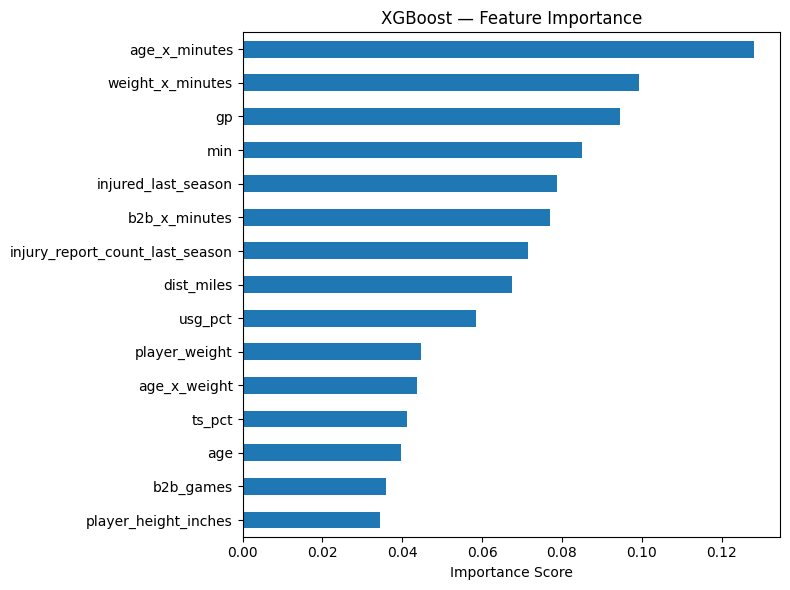


Feature importance (sorted):
  age_x_minutes                       0.1282
  weight_x_minutes                    0.0994
  gp                                  0.0944
  min                                 0.0851
  injured_last_season                 0.0788
  b2b_x_minutes                       0.0770
  injury_report_count_last_season     0.0714
  dist_miles                          0.0675
  usg_pct                             0.0585
  player_weight                       0.0447
  age_x_weight                        0.0436
  ts_pct                              0.0412
  age                                 0.0398
  b2b_games                           0.0360
  player_height_inches                0.0344


In [16]:
best_xgb = xgb_grid.best_estimator_

# Feature importance
importance = pd.Series(best_xgb.feature_importances_, index=X_train.columns)
importance = importance.sort_values(ascending=True)

plt.figure(figsize=(8, 6))
importance.plot(kind='barh')
plt.title('XGBoost — Feature Importance')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()

print("\nFeature importance (sorted):")
for feat, imp in importance.sort_values(ascending=False).items():
    print(f"  {feat:35s} {imp:.4f}")

Within the tuned XGBoost model, `age_x_minutes` receives the highest built-in feature-importance score, followed by `weight_x_minutes` and games played. These importance values describe how this specific fitted model uses features; they should not be interpreted as causal effects. The group-level ablation analysis below provides an additional check on how sets of features affect held-out error.


## 5.9 Ablation Analysis

Ablation = remove a group of features, retrain the model, see if performance gets worse.

- If MAE goes **up** → those features were helping (the model needs them)
- If MAE stays the **same** → those features weren't contributing much

Let's remove one group at a time to find out which groups matter most.

In [17]:
# Define feature groups
feature_groups = {
    'Workload':         ['min', 'gp', 'dist_miles', 'usg_pct', 'ts_pct'],
    'Physical':         ['age', 'player_height_inches', 'player_weight'],
    'Injury History':   ['injured_last_season', 'injury_report_count_last_season'],
    'Team Context':     ['b2b_games'],
    'Interactions':     ['age_x_minutes', 'weight_x_minutes', 'b2b_x_minutes', 'age_x_weight'],
}

# Baseline: full model MAE
full_mae = mean_absolute_error(y_test, y_pred_xgb_tuned)
print(f"Full model MAE: {full_mae:.3f}\n")

ablation_results = []
best_params = xgb_grid.best_params_

for group_name, group_features in feature_groups.items():
    # Remove this group
    remaining = [f for f in X_train.columns if f not in group_features]
    
    model = XGBRegressor(**best_params, random_state=RANDOM_STATE, verbosity=0)
    model.fit(X_train[remaining], y_train)
    y_pred = model.predict(X_test[remaining])
    
    ablated_mae = mean_absolute_error(y_test, y_pred)
    impact = ablated_mae - full_mae
    
    ablation_results.append({
        'Removed Group': group_name,
        'Features Removed': len(group_features),
        'MAE Without': round(ablated_mae, 3),
        'MAE Impact': round(impact, 3),
    })

ablation_df = pd.DataFrame(ablation_results).sort_values('MAE Impact', ascending=False)
print(ablation_df.to_string(index=False))

Full model MAE: 0.941

 Removed Group  Features Removed  MAE Without  MAE Impact
Injury History                 2        0.956       0.015
  Team Context                 1        0.954       0.013
  Interactions                 4        0.954       0.013
      Physical                 3        0.948       0.007
      Workload                 5        0.925      -0.016


### Ablation Analysis Takeaways

For the tuned XGBoost model:

- **Injury history (+0.015 MAE):** removing the two prior-injury features produces the largest increase in held-out MAE among the tested feature groups.
- **Team context (+0.013) and interactions (+0.013):** removing either group modestly worsens held-out MAE.
- **Physical features (+0.007):** removing age, height, and weight has a smaller effect.
- **Workload (-0.016):** removing the workload group slightly improves held-out MAE in this experiment.

These are model- and dataset-specific ablation results. They indicate predictive contribution within this fitted pipeline, not causal effects of the underlying factors on injury.


## 5.10 Sensitivity Analysis

We examine how the tuned **XGBoost** model's held-out MAE changes when one hyperparameter is varied at a time while the remaining tuned values are held fixed. XGBoost is analyzed here because it is the project's primary nonlinear model; Linear Regression nevertheless has the lowest overall held-out MAE.


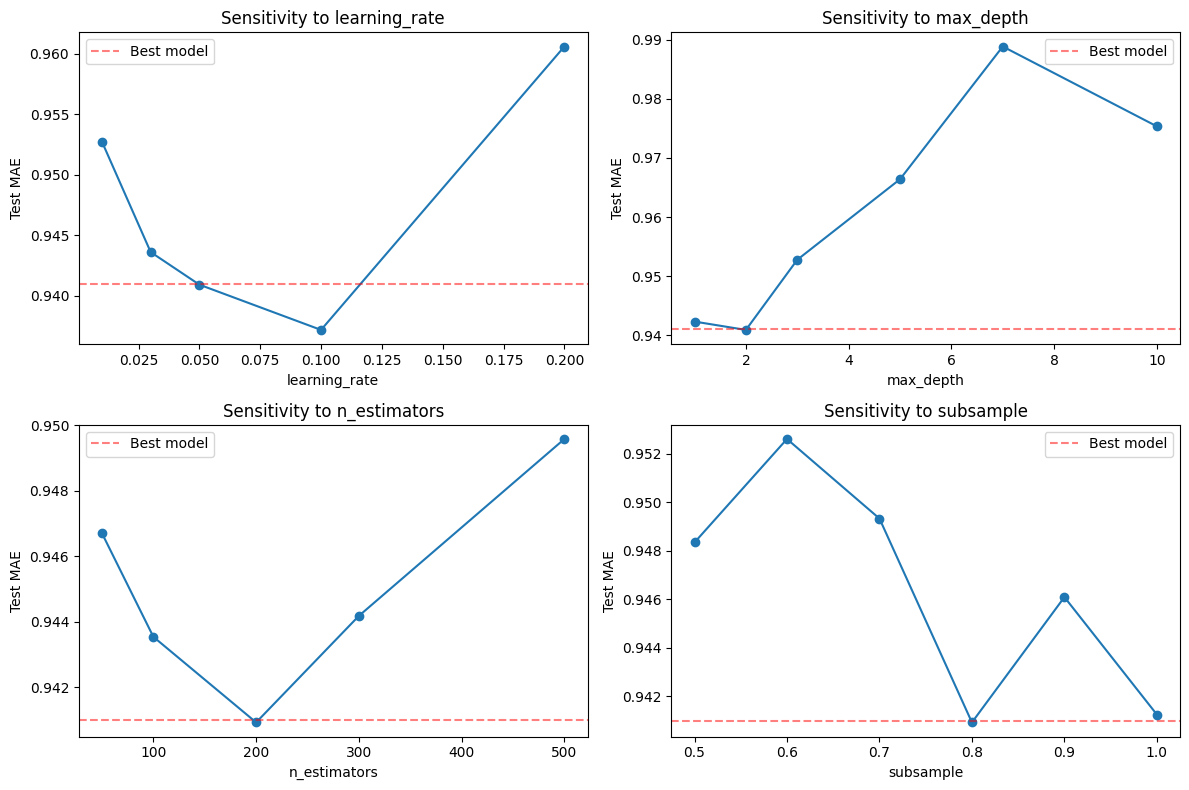

In [18]:
best = xgb_grid.best_params_  # {'learning_rate': 0.05, 'max_depth': 2, 'n_estimators': 200, 'subsample': 0.8}

sensitivity_tests = {
    'learning_rate': [0.01, 0.03, 0.05, 0.1, 0.2],
    'max_depth': [1, 2, 3, 5, 7, 10],
    'n_estimators': [50, 100, 200, 300, 500],
    'subsample': [0.5, 0.6, 0.7, 0.8, 0.9, 1.0],
}

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()

for idx, (param, values) in enumerate(sensitivity_tests.items()):
    maes = []
    for val in values:
        params = best.copy()
        params[param] = val
        model = XGBRegressor(**params, random_state=RANDOM_STATE, verbosity=0)
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        maes.append(mean_absolute_error(y_test, y_pred))
    
    axes[idx].plot(values, maes, 'o-')
    axes[idx].axhline(y=0.941, color='r', linestyle='--', alpha=0.5, label='Best model')
    axes[idx].set_xlabel(param)
    axes[idx].set_ylabel('Test MAE')
    axes[idx].set_title(f'Sensitivity to {param}')
    axes[idx].legend()

plt.tight_layout()
plt.show()

### Sensitivity Analysis Takeaways

- **`max_depth` is the most sensitive parameter in the tested range.** Increasing depth beyond the tuned shallow configuration worsens held-out MAE.
- **`learning_rate` performs best in a moderate range** in this one-at-a-time sensitivity check.
- **`n_estimators` and `subsample` are comparatively stable** around the tuned settings.

Overall, the sensitivity analysis shows that the XGBoost model generalizes better with relatively shallow trees, consistent with the broader result that additional model complexity did not outperform Linear Regression on the held-out test set.


## 5.11 Failure Analysis

Let's examine specific players where the model's prediction was most wrong, and categorize 
the types of failures. This helps us understand the model's limitations.

In [19]:
# Build failure analysis dataframe
test_analysis = test_df.copy()
test_analysis['predicted'] = y_pred_xgb_tuned
test_analysis['error'] = test_analysis['predicted'] - test_analysis[TARGET]
test_analysis['abs_error'] = test_analysis['error'].abs()

# Top 10 worst predictions
worst = test_analysis.nlargest(10, 'abs_error')
print("Top 10 Worst Predictions:")
print(worst[['min', 'gp', 'age', 'injured_last_season', 'injury_report_count_last_season',
             TARGET, 'predicted', 'error']].to_string(index=False))

Top 10 Worst Predictions:
 min  gp  age  injured_last_season  injury_report_count_last_season  target_next_season  predicted     error
36.4  75 25.0                  1.0                              3.0                   7   2.088427 -4.911573
18.3  81 31.0                  1.0                              3.0                   5   0.990270 -4.009730
16.8  25 29.0                  1.0                              4.0                   5   1.012937 -3.987063
12.3  20 21.0                  0.0                              0.0                   4   0.529381 -3.470619
12.1  73 24.0                  1.0                              1.0                   4   0.815591 -3.184409
29.9  73 31.0                  1.0                              3.0                   5   2.046504 -2.953496
14.0  53 30.0                  1.0                              3.0                   4   1.211215 -2.788785
14.4  32 28.0                  1.0                              3.0                   4   1.212435 -2.

Among the ten largest absolute errors examined for XGBoost, the errors are all underpredictions of high injury-report-count seasons. We group these cases descriptively below.


In [20]:
# Categorize failure types
print("\n=== Failure Category 1: Healthy profile, sudden spike ===")
print("Players with NO prior injury history who got 4+ injuries next season")
cat1 = worst[(worst['injured_last_season'] == 0) & (worst['injury_report_count_last_season'] == 0)]
print(f"Count: {len(cat1)}")
print(cat1[['min', 'gp', 'age', 'injured_last_season', TARGET, 'predicted', 'error']].to_string(index=False))

print("\n=== Failure Category 2: Known risk, but severity underestimated ===")
print("Players WITH prior injuries, but actual outcome far exceeded prediction")
cat2 = worst[(worst['injured_last_season'] == 1) & (worst[TARGET] >= 5)]
print(f"Count: {len(cat2)}")
print(cat2[['min', 'gp', 'age', 'injury_report_count_last_season', TARGET, 'predicted', 'error']].to_string(index=False))

print("\n=== Failure Category 3: Moderate history, moderate undershoot ===")
print("Prior injuries, target = 4, model predicted ~1")
cat3 = worst[(worst['injured_last_season'] == 1) & (worst[TARGET] == 4)]
print(f"Count: {len(cat3)}")
print(cat3[['min', 'gp', 'age', 'injury_report_count_last_season', TARGET, 'predicted', 'error']].to_string(index=False))


=== Failure Category 1: Healthy profile, sudden spike ===
Players with NO prior injury history who got 4+ injuries next season
Count: 2
 min  gp  age  injured_last_season  target_next_season  predicted     error
12.3  20 21.0                  0.0                   4   0.529381 -3.470619
23.2  63 23.0                  0.0                   4   1.231610 -2.768390

=== Failure Category 2: Known risk, but severity underestimated ===
Players WITH prior injuries, but actual outcome far exceeded prediction
Count: 4
 min  gp  age  injury_report_count_last_season  target_next_season  predicted     error
36.4  75 25.0                              3.0                   7   2.088427 -4.911573
18.3  81 31.0                              3.0                   5   0.990270 -4.009730
16.8  25 29.0                              4.0                   5   1.012937 -3.987063
29.9  73 31.0                              3.0                   5   2.046504 -2.953496

=== Failure Category 3: Moderate history, mo

### Failure Analysis Takeaways

The ten largest XGBoost errors examined here are **underpredictions** of relatively high injury-report-count seasons.

- **Sudden spike (2 cases):** players with no prior recorded injury history in the selected features who have a target count of 4.
- **Severity underestimated (4 cases):** players with prior injury-report history whose following-season counts are substantially higher than the model prediction.
- **Moderate undershoot (4 cases):** observations with a target count of 4 and predictions near 1.

The target is highly zero-heavy (50.7% zeros), and rare high-count outcomes are difficult for the fitted model to capture. Potential extensions identified by the project include more granular injury-type information, multi-season workload trends, or reframing the task as classification or a count-modeling problem.


## 5.12 Summary & Handoff to NB06

**Held-out model comparison:** Linear Regression achieved the lowest test MAE (**0.928**), followed by XGBoost (**0.941**), Random Forest (**0.964**), and the mean-prediction baseline (**1.048**).

**Key findings:**

- All three supervised models improve only modestly over the baseline, indicating limited predictive signal in the available features.
- Greater model complexity does not improve held-out performance in this experiment; Linear Regression generalizes slightly better than the tuned tree-based models.
- In XGBoost ablation analysis, removing the injury-history feature group produces the largest increase in held-out MAE among the tested groups.
- The largest XGBoost errors are underpredictions of high injury-report-count seasons, highlighting difficulty modeling rare high-count outcomes.

**Next:** NB06 explores whether the same player features form meaningful unsupervised clusters.
